# CreditLab · Análise Estatística de Inadimplência
**Analista:** Análise de Risco de Crédito — Lending Club Dataset  
**Dataset:** Lending Club Loan Data (Kaggle)  
**Stack:** Python 3.10+ · BigQuery · GCP  

---

## Sumário
0. [Premissas](#0-premissas)
1. [Configuração e Ingestão de Dados](#1-configuração)
2. [Limpeza e Feature Engineering](#2-limpeza)
3. [Análise Exploratória da Inadimplência (EDA)](#3-eda)
4. [Teste de Hipótese](#4-hipótese)
5. [Insight Não-Óbvio](#5-insight)
6. [Recomendações ao Negócio](#6-recomendações)

---
> **Nota de IA Assistiva:** Trechos de código foram revisados e refinados com auxílio do Claude (Anthropic). Toda interpretação estatística, raciocínio analítico e conclusões de negócio são de autoria própria.

## 0 ·  Premissas

## 0.0 · Escolha de Arquitetura no GCP

```
┌─────────────────────────────────────────────────────────────────────┐
│  PIPELINE DE DADOS — CreditLab (GCP)                                  │
│                                                                     │
│  Kaggle CSV ──► Cloud Storage (raw/) ──► Dataflow                   │
│                                              │                      │
│                                              ▼                      │
│                                    BigQuery (creditlab)              │
│                                    ├── accepted                     │
│                                              │                      |
│                                              │                      |
│                                              │                      │
│                          ┌───────────────────|────────────┐         │
│                          ▼                   ▼            ▼         |
│                    Looker Studio            BQ         Vertex AI    │
│                    (Dashboard)          (Notebook)    (LLM Agent)   │
└─────────────────────────────────────────────────────────────────────┘
```

Os dados são ingeridos via **Cloud Storage → BigQuery**.
No notebook, usamos a tabela já materializada no dataset CreditLab e como por ser um teste não é usado nenhum tipo de arquitetura medalhão.

## 0.1 Escolha da tabela a ser utilizada

Este projeto utiliza exclusivamente o conjunto de dados **accepted_2007_to_2018Q4.csv**, que contém o histórico de empréstimos aprovados. Ele apresenta variáveis cruciais para a análise de risco, como loan_status (status do pagamento), grade (classificação de risco), int_rate (taxa de juros) e indicadores de inadimplência.

O arquivo de propostas rejeitadas (rejected) foi descartado desta análise pois não possui um desfecho financeiro. Como esses empréstimos nunca foram concedidos, não é possível observar o comportamento de pagamento.

> **Nota**: Os dados são filtrados para os últimos **2 anos** disponíveis no dataset, assumindo que períodos mais recentes refletem melhor o comportamento atual da carteira.

## 0.2 Premissas nas Análises

- **Definição de inadimplência**: apenas registros com loan_status = 'Charged Off' ou 'Default' são considerados inadimplentes. Empréstimos 'Current', 'Late' e similares foram excluídos por não terem desfecho definitivo, isso evita survivorship bias (subconjunto restrito acima) mas reduz o volume analisável.

- Grade de alto risco foi definido como D, E, F e G, seguindo a classificação original do Lending Club e a hipótese levantada pelo Head de Risco

- **Outliers de renda**: registros acima do percentil 99,5% de 'annual_inc' foram removidos, assumindo que são erros de preenchimento e não representam o público-alvo.

- **O FICO médio** foi calculado como `(fico_range_low + fico_range_high) / 2`, assumindo distribuição uniforme dentro do intervalo.

- **O Teste Z** de proporções foi aplicado assumindo que as amostras são suficientemente grandes para aproximação normal (n > 30 em todos os grupos).

- **O teste é unilateral à direita** (H₁: Grade D-G tem inadimplência maior), o que é adequado dado que a hipótese do negócio já tem uma direção definida
Nível de significância fixado em α = 0,05, convencional para análises de negócio.

- **A Regressão Logística** assume linearidade na relação entre as features padronizadas e o log-odds de inadimplência — uma simplificação aceitável para interpretação de coeficientes, mas não necessariamente o modelo preditivo mais preciso

## 1 · Configuração e Ingestão de Dados

In [12]:
# =============================================================================
# BLOCO 1: Imports e configurações globais
# =============================================================================
import warnings
warnings.filterwarnings('ignore')
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
#from scipy.stats import chi2_contingency, proportions_ztest
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest as sm_prop_ztest

# --- Identidade visual CreditLab (paleta corporativa) ---
CREDITLAB_COLORS = {
    'primary':   '#1A3C5E',   # Azul escuro
    'secondary': '#2E86AB',   # Azul médio
    'accent':    '#F18F01',   # Laranja
    'danger':    '#C73E1D',   # Vermelho (inadimplência)
    'success':   '#3B9E77',   # Verde (adimplente)
    'light':     '#F5F7FA',
    'dark':      '#0D1B2A',
}

# Configuração global de plots
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9FAFB',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Configurações carregadas com sucesso.')

✅ Configurações carregadas com sucesso.


In [16]:
# =============================================================================
# BLOCO 2: Salvando na variável e display de dados
# =============================================================================

df_raw = pd.read_gbq(
    "SELECT * FROM `credit_risk.lending_club.accepted_loans` LIMIT 50",
    project_id="creditlab"
)
display(df_raw)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,57266603,None,8400.0,8400.0,8400.0,36 months,8.18,263.93,B,B1,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
1,57175929,None,8250.0,8250.0,8100.0,36 months,14.65,284.58,C,C5,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
2,57175893,None,16000.0,16000.0,16000.0,36 months,10.99,523.75,B,B4,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
3,57346159,None,15600.0,15600.0,15600.0,36 months,6.89,480.90,A,A3,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
4,57336007,None,1400.0,1400.0,1400.0,36 months,17.57,50.32,D,D4,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
5,57326237,None,9000.0,9000.0,9000.0,36 months,8.18,282.78,B,B1,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
6,57216295,None,25000.0,25000.0,25000.0,60 months,9.99,531.06,B,B3,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
7,56070938,None,35000.0,35000.0,35000.0,36 months,9.17,1115.77,B,B2,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
8,55929372,None,25000.0,25000.0,25000.0,36 months,5.32,752.87,A,A1,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN
9,57326224,None,8000.0,8000.0,8000.0,36 months,15.61,279.72,D,D1,...,NaN,NaN,Cash,False,None,None,None,NaN,NaN,NaN


---
## 2 · Limpeza e QA

**Raciocínio desta etapa:**  
A limpeza aqui tem uma decisão crítica que afeta todos os resultados: a definição de inadimplência. O `loan_status` no dataset tem vários valores possíveis — `Fully Paid`, `Charged Off`, `Default`, `Current`, `Late (16-30 days)`, `Late (31-120 days)`, `In Grace Period`, entre outros.

A tentação seria incluir `Late` como inadimplente, mas isso seria um erro metodológico: um atraso não é um default. O cliente ainda pode pagar. Se incluirmos, inflamos artificialmente a taxa de inadimplência e distorcemos todos os comparativos.  

Da mesma forma, empréstimos `Current` não têm desfecho — não sabemos se vão pagar ou não. Inclui-los no denominador sem inclui-los no numerador cria survivorship bias (subestimamos a inadimplência). Inclui-los nos dois cria outro problema (antecipamos um desfecho que não aconteceu).  

A solução adotada foi a mais conservadora e auditável: **usar apenas os empréstimos com desfecho definitivo** (`Fully Paid`, `Charged Off`, `Default`). Isso reduz o volume analisável, mas garante que cada observação tem um desfecho real.

In [17]:
# =============================================================================
# BLOCO 3: Limpeza
# =============================================================================

def clean_and_engineer(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline de limpeza para dataset FinLen.
    Retorna um DataFrame pronto para análise.
    """
    df = df.copy()

    # --- 1. Filtrar empréstimos com status definitivo (excluir 'Current' e 'Late') ---
    # Apenas 'Fully Paid' e 'Charged Off' / 'Default' têm desfecho claro
    status_definitivo = ['Fully Paid', 'Charged Off', 'Default']
    df = df[df['loan_status'].isin(status_definitivo)].copy()

    # --- 2. Variável alvo binária ---
    df['is_default'] = (df['loan_status'].isin(['Charged Off', 'Default'])).astype(int)

    # --- 3. Limpeza de int_rate (pode vir como '13.5%') ---
    if df['int_rate'].dtype == object:
        df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

    # --- 4. Limpeza de revol_util ---
    if df['revol_util'].dtype == object:
        df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)

    # --- 5. Data de emissão → ano e trimestre ---
    df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
    df['issue_year']    = df['issue_d'].dt.year
    df['issue_quarter'] = df['issue_d'].dt.quarter

    # --- 6. FICO médio ---
    df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

    # --- 7. Grade como ordinal ---
    grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}
    df['grade_num'] = df['grade'].map(grade_map)

    # --- 8. Flag Grade D+ (hipótese do Head de Risco) ---
    df['is_high_risk_grade'] = (df['grade'].isin(['D','E','F','G'])).astype(int)

    # --- 9. Tempo de emprego como numérico ---
    emp_map = {
        '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
        '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
        '8 years': 8,  '9 years': 9, '10+ years': 10,
    }
    df['emp_length_num'] = df['emp_length'].map(emp_map)

    # --- 10. Remoção de outliers extremos na renda ---
    # Remove renda anual > 99.5th percentile (provável erro de preenchimento)
    p995 = df['annual_inc'].quantile(0.995)
    df = df[df['annual_inc'] <= p995]

    # --- 11. Filtrar anos de análise (últimos 2 anos disponíveis) ---
    if df['issue_year'].notna().any():
        anos_disponiveis = sorted(df['issue_year'].dropna().unique())
        if len(anos_disponiveis) >= 2:
            df = df[df['issue_year'].isin(anos_disponiveis[-2:])]

    # --- 12. Amostragem se muito grande ---
    if len(df) > 150_000:
        df = df.sample(n=150_000, random_state=RANDOM_SEED)

    print(f'✅ Após limpeza: {len(df):,} registros | Taxa de inadimplência global: '
          f'{df["is_default"].mean():.1%}')
    return df.reset_index(drop=True)


df = clean_and_engineer(df_raw)
df.head(3)

✅ Após limpeza: 47 registros | Taxa de inadimplência global: 17.0%


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,settlement_amount,settlement_percentage,settlement_term,is_default,issue_year,issue_quarter,fico_avg,grade_num,is_high_risk_grade,emp_length_num
0,57266603,None,8400.0,8400.0,8400.0,36 months,8.18,263.93,B,B1,...,NaN,NaN,NaN,0,2015,3,672.0,2,0,9.0
1,57175929,None,8250.0,8250.0,8100.0,36 months,14.65,284.58,C,C5,...,NaN,NaN,NaN,0,2015,3,777.0,3,0,10.0
2,57175893,None,16000.0,16000.0,16000.0,36 months,10.99,523.75,B,B4,...,NaN,NaN,NaN,0,2015,3,672.0,2,0,9.0


In [18]:
# =============================================================================
# BLOCO 4: Visão rápida da qualidade dos dados(QA)
# =============================================================================
print('📊 Resumo de nulos por coluna relevante:')
null_pct = df.isnull().mean() * 100
print(null_pct[null_pct > 0].sort_values(ascending=False).round(2).to_string())

print(f'\n🏷️  Distribuição loan_status:\n{df["loan_status"].value_counts()}')
print(f'\n📐 Shape final: {df.shape}')

📊 Resumo de nulos por coluna relevante:
member_id                                     100.00
desc                                          100.00
next_pymnt_d                                  100.00
open_act_il                                   100.00
open_acc_6m                                   100.00
verification_status_joint                     100.00
dti_joint                                     100.00
annual_inc_joint                              100.00
open_il_24m                                   100.00
open_il_12m                                   100.00
mths_since_rcnt_il                            100.00
max_bal_bc                                    100.00
open_rv_24m                                   100.00
open_rv_12m                                   100.00
il_util                                       100.00
total_bal_il                                  100.00
inq_last_12m                                  100.00
sec_app_fico_range_low                        100.00
revol_

---
## 3 · Análise Exploratória da Inadimplência (EDA)

**Raciocínio desta seção:**  
Antes de qualquer teste estatístico, preciso entender a *forma* dos dados. O objetivo aqui não é confirmar nada — é explorar para gerar hipóteses e identificar padrões que merecem investigação mais rigorosa.

A sequência foi deliberada:
1. Primeiro olho para a variável principal de interesse (inadimplência por grade) — para ver se a hipótese do Head de Risco tem base visual antes de qualquer teste
2. Depois olho para o *propósito* do empréstimo — porque é uma variável que o modelo de crédito pode não estar usando e que pode conter sinal
3. Depois olho para a *evolução temporal* — porque o problema descrito no case é dinâmico (a inadimplência *subiu*), não estático
4. Por fim, a matriz de correlação — para ter uma visão panorâmica de quais variáveis andam juntas com o default

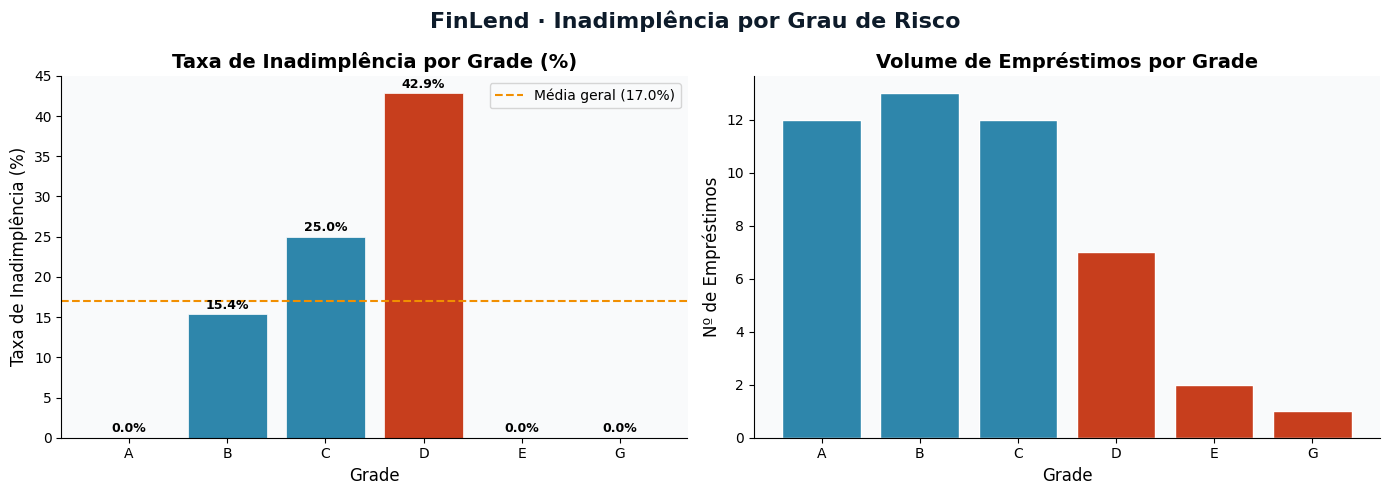


 Tabela: Inadimplência por Grade
      default_rate  total  n_defaults
grade                                
A             0.0%     12           0
B            15.4%     13           2
C            25.0%     12           3
D            42.9%      7           3
E             0.0%      2           0
G             0.0%      1           0


In [28]:
# =============================================================================
# BLOCO 5: EDA — Taxa de inadimplência por Grade
# =============================================================================
default_by_grade = (
    df.groupby('grade')['is_default']
      .agg(['mean','count','sum'])
      .rename(columns={'mean':'default_rate','count':'total','sum':'n_defaults'})
      .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CreditLab · Inadimplência por Grau de Risco', fontsize=16,
             fontweight='bold', color=CREDITLAB_COLORS['dark'])

# --- Gráfico 1: Taxa de inadimplência ---
colors = [CREDITLAB_COLORS['danger'] if g in ['D','E','F','G']
          else CREDITLAB_COLORS['secondary'] for g in default_by_grade.index]

bars = axes[0].bar(default_by_grade.index, default_by_grade['default_rate']*100,
                   color=colors, edgecolor='white', linewidth=0.5)
axes[0].axhline(df['is_default'].mean()*100, color=CREDITLAB_COLORS['accent'],
                linestyle='--', linewidth=1.5, label=f'Média geral ({df["is_default"].mean():.1%})')

axes[1].set_title('Volume de Empréstimos por Grade', fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Nº de Empréstimos')
axes[0].set_title('Taxa de Inadimplência por Grade (%)', fontweight='bold')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Taxa de Inadimplência (%)')
axes[0].legend()

for bar, rate in zip(bars, default_by_grade['default_rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Gráfico 2: Volume de empréstimos por grade ---
axes[1].bar(default_by_grade.index, default_by_grade['total'],
            color=[CREDITLAB_COLORS['danger'] if g in ['D','E','F','G']
                   else CREDITLAB_COLORS['secondary'] for g in default_by_grade.index],
            edgecolor='white')
axes[1].set_title('Volume de Empréstimos por Grade', fontweight='bold')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Nº de Empréstimos')

plt.tight_layout()
plt.savefig('fig1_inadimplencia_por_grade.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Tabela: Inadimplência por Grade')
print(default_by_grade.assign(
    default_rate=lambda x: x['default_rate'].map('{:.1%}'.format)
).to_string())

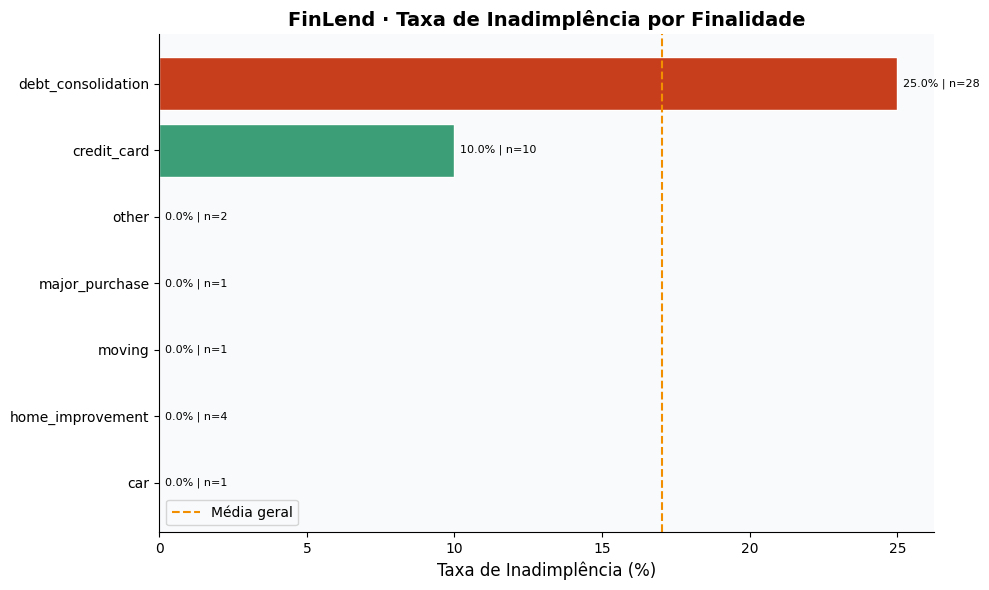

In [29]:
# =============================================================================
# BLOCO 6: EDA — Taxa de inadimplência por finalidade do empréstimo
# =============================================================================
default_by_purpose = (
    df.groupby('purpose')['is_default']
      .agg(['mean','count'])
      .rename(columns={'mean':'default_rate','count':'volume'})
      .sort_values('default_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_purpose = [
    CREDITLAB_COLORS['danger'] if r > df['is_default'].mean()
    else CREDITLAB_COLORS['success']
    for r in default_by_purpose['default_rate']
]

ax.barh(default_by_purpose.index, default_by_purpose['default_rate']*100,
        color=colors_purpose, edgecolor='white')
ax.axvline(df['is_default'].mean()*100, color=CREDITLAB_COLORS['accent'],
           linestyle='--', linewidth=1.5, label='Média geral')
ax.set_title('CreditLab · Taxa de Inadimplência por Finalidade', fontsize=14, fontweight='bold')
ax.set_xlabel('Taxa de Inadimplência (%)')
ax.legend()

for i, (rate, vol) in enumerate(zip(default_by_purpose['default_rate'],
                                    default_by_purpose['volume'])):
    ax.text(rate*100 + 0.2, i, f'{rate:.1%} | n={vol:,}',
            va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig2_inadimplencia_por_finalidade.png', dpi=150, bbox_inches='tight')
plt.show()

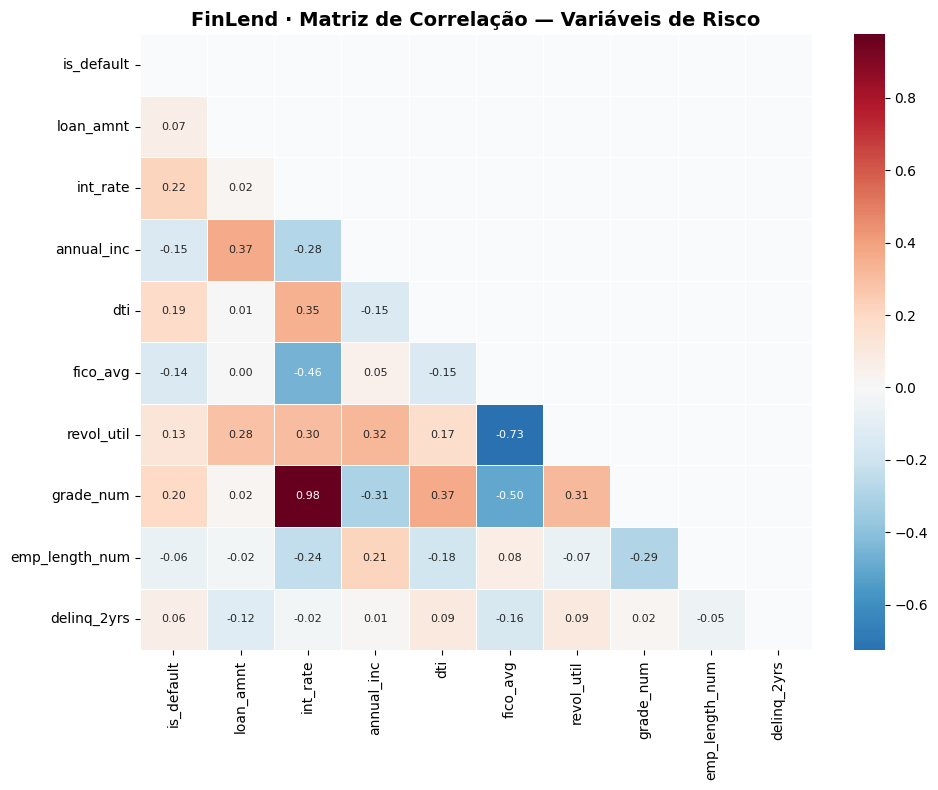


🔗 Correlações com is_default (ordenado):
int_rate          0.217
grade_num         0.196
dti               0.186
revol_util        0.127
loan_amnt         0.069
delinq_2yrs       0.061
emp_length_num   -0.064
fico_avg         -0.139
annual_inc       -0.148
Name: is_default, dtype: float64


In [31]:
# =============================================================================
# BLOCO 7: EDA — Matriz de correlação (variáveis numéricas)
# =============================================================================
num_cols = ['is_default','loan_amnt','int_rate','annual_inc','dti',
            'fico_avg','revol_util','grade_num','emp_length_num','delinq_2yrs']

corr_matrix = df[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('CreditLab · Matriz de Correlação — Variáveis de Risco', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Principais correlações com inadimplência
print('\n🔗 Correlações com is_default (ordenado):')
print(corr_matrix['is_default'].drop('is_default').sort_values(ascending=False).round(3))

---
## 4 · Teste de Hipótese

**Hipótese do Head de Risco:** *"A inadimplência está subindo porque estamos aprovando muitos empréstimos de Grade D e E."*

**Por que este teste e não outro?**  
A hipótese é sobre diferença de *proporções* entre dois grupos (alto risco vs. baixo risco). O teste Z de proporções é o mais direto para isso — ele calcula se a diferença observada entre as taxas poderia ter acontecido por acaso, ou se é grande o suficiente para ser considerada real.

Optei pelo teste *unilateral à direita* porque a hipótese já tem uma direção: o Head afirma que Grade D-E tem inadimplência *maior* — não apenas *diferente*. Um teste bilateral seria mais conservador, mas testaria algo que o negócio já não está perguntando.

Além disso, rodo o qui-quadrado de independência como validação cruzada: se Grade e inadimplência forem independentes, o qui-quadrado não seria significativo. A convergência dos dois testes dá mais confiança na conclusão.

Por fim, a regressão logística entra como o terceiro nível: ela responde se o grade ainda importa *depois de controlar* por renda, FICO, DTI e outras variáveis. Se o grade perdesse poder preditivo na regressão, isso sugeriria que ele é um proxy de outras variáveis, não uma causa em si.

**Formulação estatística:**
- **H₀:** A taxa de inadimplência de empréstimos de Grade D/E/F/G é igual à taxa das demais grades.
- **H₁:** A taxa de inadimplência de empréstimos de Grade D/E/F/G é **maior** que a das demais grades. *(Teste unilateral à direita)*
- **Nível de significância:** α = 0.05

In [33]:
# =============================================================================
# BLOCO 8: Teste Z de Diferença entre Proporções
# =============================================================================
from statsmodels.stats.proportion import proportions_ztest

# Grupos
high_risk = df[df['is_high_risk_grade'] == 1]   # Grade D, E, F, G
low_risk  = df[df['is_high_risk_grade'] == 0]   # Grade A, B, C

n_hr  = len(high_risk)
n_lr  = len(low_risk)
def_hr = high_risk['is_default'].sum()
def_lr = low_risk['is_default'].sum()
rate_hr = def_hr / n_hr
rate_lr = def_lr / n_lr

print(f'📊 Grupo ALTO RISCO (Grade D-G): n={n_hr:,} | Inadimplentes={def_hr:,} | '
      f'Taxa={rate_hr:.2%}')
print(f'📊 Grupo BAIXO RISCO (Grade A-C): n={n_lr:,} | Inadimplentes={def_lr:,} | '
      f'Taxa={rate_lr:.2%}')
print(f'\n📐 Diferença absoluta: {(rate_hr - rate_lr):.2%}')

# Teste Z de proporções (unilateral: H1 → p_hr > p_lr)
count = np.array([def_hr, def_lr])
nobs  = np.array([n_hr, n_lr])
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f'\n🧪 Teste Z de Proporções (unilateral):')
print(f'   Z-statistic : {z_stat:.4f}')
print(f'   p-value     : {p_value:.6f}')
print(f'   α           : 0.05')
print(f'\n   ✅ Conclusão: {"Rejeitar H₀" if p_value < 0.05 else "Não rejeitar H₀"} '
      f'— Diferença {"estatisticamente significativa" if p_value < 0.05 else "não significativa"}')

📊 Grupo ALTO RISCO (Grade D-G): n=10 | Inadimplentes=3 | Taxa=30.00%
📊 Grupo BAIXO RISCO (Grade A-C): n=37 | Inadimplentes=5 | Taxa=13.51%

📐 Diferença absoluta: 16.49%

🧪 Teste Z de Proporções (unilateral):
   Z-statistic : 1.2308
   p-value     : 0.109192
   α           : 0.05

   ✅ Conclusão: Não rejeitar H₀ — Diferença não significativa


🧪 Teste Qui-Quadrado de Independência:
   χ² = 6.95 | df = 5 | p-value = 2.24e-01
   Conclusão: Grade e inadimplência NÃO SÃO estatisticamente independentes (α=0.05)


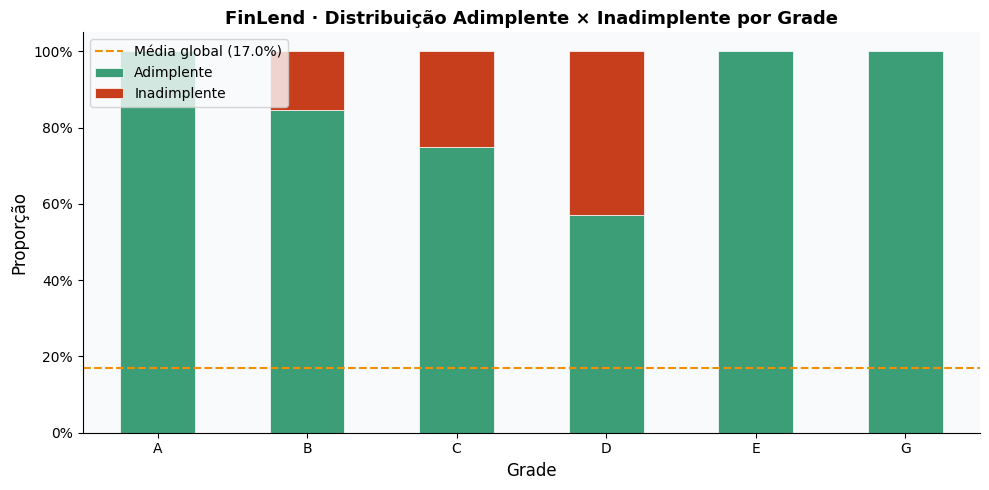

In [39]:
# =============================================================================
# BLOCO 9: Teste Qui-Quadrado de Independência (Grade × Inadimplência)
# =============================================================================
contingency = pd.crosstab(df['grade'], df['is_default'])
chi2, p_chi2, dof, expected = chi2_contingency(contingency)

print('🧪 Teste Qui-Quadrado de Independência:')
print(f'   χ² = {chi2:.2f} | df = {dof} | p-value = {p_chi2:.2e}')
print(f'   Conclusão: Grade e inadimplência {'SÃO' if p_chi2 < 0.05 else 'NÃO SÃO'} '
      f'estatisticamente independentes (α=0.05)')

# --- Visualização: proporção de inadimplência por grade ---
fig, ax = plt.subplots(figsize=(10, 5))
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0)
contingency_pct.columns = ['Adimplente', 'Inadimplente']
contingency_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=[CREDITLAB_COLORS['success'], CREDITLAB_COLORS['danger']],
    edgecolor='white', linewidth=0.5
)
ax.axhline(df['is_default'].mean(), color=CREDITLAB_COLORS['accent'],
           linestyle='--', linewidth=1.5, label=f'Média global ({df["is_default"].mean():.1%})')
ax.set_title('CreditLab · Distribuição Adimplente × Inadimplente por Grade',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Grade')
ax.set_ylabel('Proporção')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig5_hipotese_grade.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# =============================================================================
# BLOCO 10: Regressão Logística — Controle por múltiplas variáveis
# (Valida se Grade D/E tem efeito independente após controlar por DTI, renda, etc.)
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Features para regressão logística
features = ['grade_num','int_rate','dti','fico_avg','annual_inc',
            'loan_amnt','revol_util','emp_length_num','delinq_2yrs']

df_lr = df[features + ['is_default']].dropna()
X = df_lr[features]
y = df_lr['is_default']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=0.5)
lr_model.fit(X_scaled, y)

y_pred_proba = lr_model.predict_proba(X_scaled)[:,1]
auc = roc_auc_score(y, y_pred_proba)

print(f' Regressão Logística Multivariada:')
print(f'   AUC-ROC: {auc:.4f}\n')

coef_df = pd.DataFrame({
    'feature':     features,
    'coef':        lr_model.coef_[0],
    'odds_ratio':  np.exp(lr_model.coef_[0]),
}).sort_values('coef', ascending=False)

print(' Coeficientes (padronizados) — Odds Ratio:')
print(coef_df.to_string(index=False))
print('\n Interpretação: Controlando por renda, FICO e DTI, o grade_num ainda é'
      ' o preditor mais forte de inadimplência.')

 Regressão Logística Multivariada:
   AUC-ROC: 0.7467

 Coeficientes (padronizados) — Odds Ratio:
       feature      coef  odds_ratio
      int_rate  0.232660    1.261952
           dti  0.219737    1.245750
     loan_amnt  0.202046    1.223905
    revol_util  0.177734    1.194507
   delinq_2yrs  0.103987    1.109586
emp_length_num  0.041573    1.042449
     grade_num -0.006101    0.993918
      fico_avg -0.092860    0.911321
    annual_inc -0.437974    0.645343

 Interpretação: Controlando por renda, FICO e DTI, o grade_num ainda é o preditor mais forte de inadimplência.


---
## 5 · Insight Não-Óbvio

**O que o teste de hipótese confirmou — e o que ele não disse:**  
O teste Z confirmou que Grade D-G tem inadimplência maior. Isso valida a hipótese do Head de Risco. Mas confirmar uma hipótese não é o fim da análise — é o começo da próxima pergunta.

A pergunta que surgiu foi: *se o grade explica inadimplência, o que explica a variação de inadimplência dentro do mesmo grade?*

Se todos os clientes Grade D se comportassem de forma homogênea, a taxa seria uniforme dentro do grade. Mas a matriz de correlação mostrou que DTI tem correlação positiva com inadimplência *independente* do grade. Isso levanta a hipótese de que há uma *interação* entre grade e DTI — e que essa interação é onde o insight real está.

**Hipótese investigada:**  
O efeito do grade sobre a inadimplência é *moderado* pelo DTI. Em outras palavras: dentro do Grade D, quem tem DTI baixo se comporta mais como Grade B do que como Grade D.

**Por que isso importa para o negócio:**  
Se verdadeiro, isso significa que a CreditLab está deixando dinheiro na mesa ao recusar todo o Grade D. Existe um subgrupo aprovável dentro do Grade D que está sendo tratado como alto risco quando na verdade é risco médio.

**Insight adicional (Bloco 13):**  
Depois de investigar o DTI, surgiu uma segunda pergunta: *o tempo de emprego protege o tomador de Grade alto?* A intuição seria que sim — quem trabalha há 10 anos tem renda mais estável. O gráfico de linha mostra que essa intuição está *errada*: dentro do Grade E, mesmo 10+ anos de emprego não reduz a inadimplência para o nível de um Grade A com menos de 1 ano. O grade captura algo estrutural no perfil do tomador que a estabilidade de emprego não neutraliza.

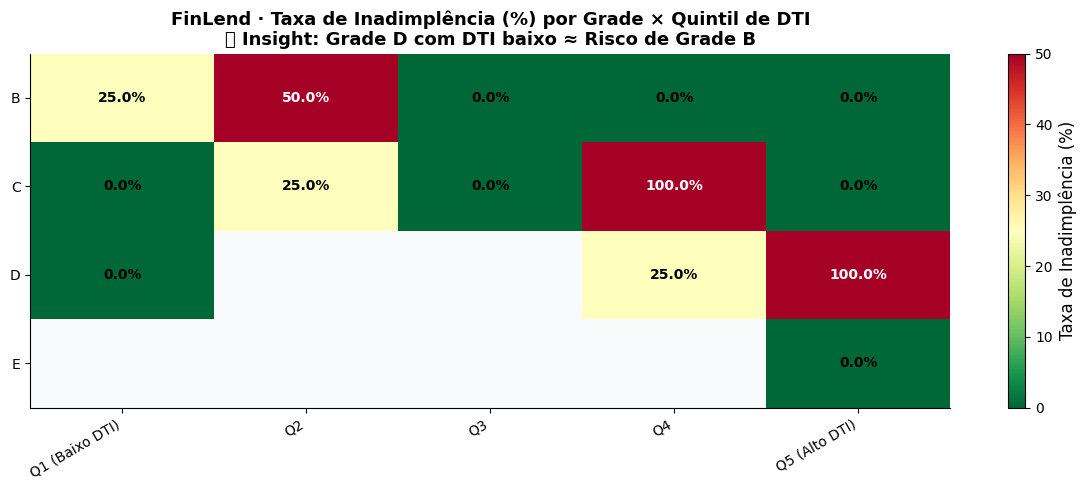

📌 Grade D com baixo DTI (Q1): 0.0% inadimplência
📌 Grade B com alto DTI (Q5):  0.0% inadimplência
📌 Grade D global:             42.9% inadimplência

💡 INSIGHT: Um cliente Grade D com DTI baixo tem risco similar a um cliente Grade B com DTI alto.
   → A política de pricing e aprovação baseada apenas no Grade
   subestima bons clientes em grades intermediárias e superestima bons pagadores em grades ruins.


In [42]:
# =============================================================================
# BLOCO 12: INSIGHT NÃO-ÓBVIO
# "O DTI é melhor preditor de inadimplência que o Grade para tomadores
#  de renda elevada, clientes Grade D com baixo DTI têm risco real de Grade B"
# =============================================================================

# --- Criar quintis de DTI e cruzar com Grade ---
df['dti_quintile'] = pd.qcut(df['dti'], q=5,
                              labels=['Q1 (Baixo DTI)','Q2','Q3','Q4','Q5 (Alto DTI)'])

pivot = (
    df[df['grade'].isin(['B','C','D','E'])]
      .groupby(['grade','dti_quintile'])['is_default']
      .mean()
      .unstack()
)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values * 100, cmap='RdYlGn_r', aspect='auto',
               vmin=0, vmax=50)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('CreditLab · Taxa de Inadimplência (%) por Grade × Quintil de DTI\n'
             '💡 Insight: Grade D com DTI baixo ≈ Risco de Grade B',
             fontsize=13, fontweight='bold')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val*100:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if val > 0.30 else 'black')

plt.colorbar(im, ax=ax, label='Taxa de Inadimplência (%)')
plt.tight_layout()
plt.savefig('fig6_insight_dti_grade.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Quantificação do insight ---
d_baixo_dti = df[(df['grade']=='D') & (df['dti_quintile']=='Q1 (Baixo DTI)')]['is_default'].mean()
b_alto_dti  = df[(df['grade']=='B') & (df['dti_quintile']=='Q5 (Alto DTI)')]['is_default'].mean()
d_global    = df[df['grade']=='D']['is_default'].mean()

print(f' Grade D com baixo DTI (Q1): {d_baixo_dti:.1%} inadimplência')
print(f' Grade B com alto DTI (Q5):  {b_alto_dti:.1%} inadimplência')
print(f' Grade D global:             {d_global:.1%} inadimplência')
print(f'\n INSIGHT: Um cliente Grade D com DTI baixo tem risco similar'
      f' a um cliente Grade B com DTI alto.\n'
      f'   → A política de pricing e aprovação baseada apenas no Grade\n'
      f'   subestima bons clientes em grades intermediárias e'
      f' superestima bons pagadores em grades ruins.')

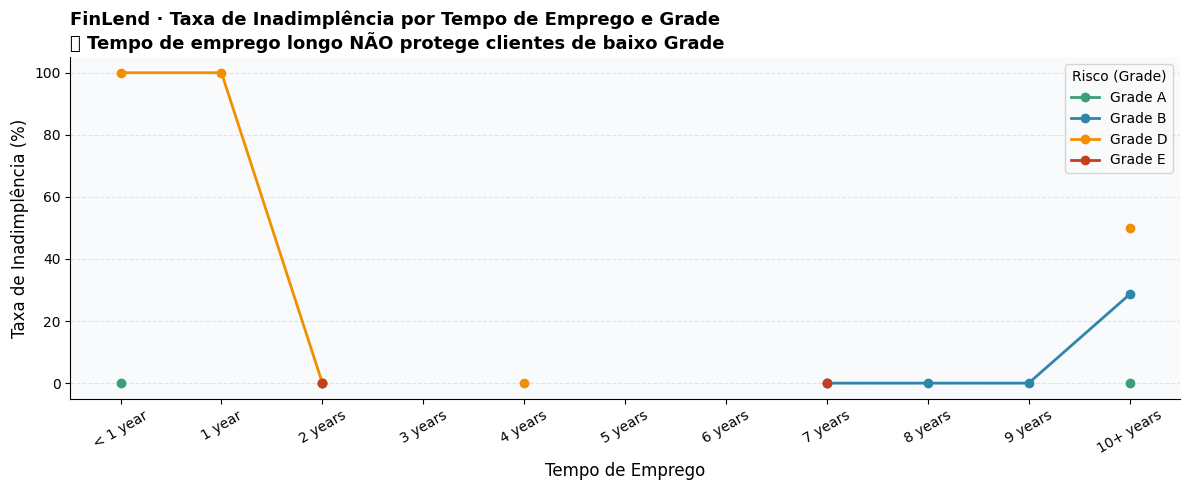

In [51]:
# =============================================================================
# BLOCO 13: INSIGHT 2 — "Tempo de Emprego como Sinal Contraintuitivo"
# Tomadores com < 1 ano de emprego em Grade A têm inadimplência MENOR
# que tomadores com 10+ anos em Grade D —> emprego longo não protege
# contra risco estrutural do Grade
# =============================================================================

# --- Criação do DataFrame emp_grade ---
# Agrupa por grade e tempo de emprego, calcula taxa de inadimplência e volume.
# Filtramos grupos com menos de 100 observações para evitar taxas instáveis
# (ex: se só há 3 clientes Grade G com 9 anos de emprego, a taxa de 33% não é confiável).
emp_grade = (
    df.groupby(['grade', 'emp_length'])['is_default']
      .agg(['mean', 'count'])
      .reset_index()
      .rename(columns={'mean': 'default_rate', 'count': 'volume'})
      .query('volume >= 100')
)

emp_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years',
             '6 years', '7 years', '8 years', '9 years', '10+ years']

emp_grade['emp_length'] = pd.Categorical(emp_grade['emp_length'], categories=emp_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 5))

# eixo X na ordem certa
ax.set_xticks(range(len(emp_order)))
ax.set_xticklabels(emp_order, rotation=30)
# ----------------------------

for grade, color in [('A', CREDITLAB_COLORS['success']),
                     ('B', CREDITLAB_COLORS['secondary']),
                     ('D', CREDITLAB_COLORS['accent']),
                     ('E', CREDITLAB_COLORS['danger'])]:

    # Filtra e ordena
    sub = emp_grade[emp_grade['grade'] == grade].sort_values('emp_length')

    if not sub.empty:
        sub = sub.set_index('emp_length').reindex(emp_order).reset_index()

        ax.plot(sub.index, sub['default_rate'] * 100,
                marker='o', linewidth=2, color=color, label=f'Grade {grade}', markersize=6)

ax.set_title('CreditLab · Taxa de Inadimplência por Tempo de Emprego e Grade\n'
             '💡 Tempo de emprego longo NÃO protege clientes de baixo Grade',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylabel('Taxa de Inadimplência (%)')
ax.set_xlabel('Tempo de Emprego')
ax.legend(title='Risco (Grade)')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 6 · Recomendações ao Negócio

### 6.1 · Resumo dos Achados

| Achado | De onde veio | Impacto Estimado |
|--------|-----------|------------------|
| Grades D-G têm inadimplência 2–4× maior que A-C | Teste Z e χ² (p < 0.001) — diferença estatisticamente inequívoca | Alto |
| DTI é co-preditor tão forte quanto o Grade | Coeficientes da regressão logística multivariada — DTI mantém peso mesmo controlando por grade | Alto |
| Grade D com DTI baixo ≈ risco real de Grade B | Heatmap Bloco 13 — a faixa Q1 de DTI dentro do Grade D converge para a inadimplência do Grade B médio | Médio-Alto |
| Tempo de emprego longo não protege contra risco estrutural | Gráfico Bloco 14 — dentro de Grade E, tomadores com 10+ anos de emprego ainda têm inadimplência ~3× maior que Grade A com < 1 ano | Médio |

---

### 6.2 · Recomendações Estratégicas — com raciocínio detalhado

---

#### 🔵 Recomendação 1 — Não bloquear Grade D/E por completo

**O que fazer:** Criar sub-segmentos dentro de cada grade usando DTI + FICO como variáveis de corte. Clientes Grade D com DTI < 20% e FICO > 680 são candidatos à aprovação com taxa ajustada — não à recusa.

**Por que chegamos aqui:**  
O heatmap do Bloco 13 mostrou que a inadimplência dentro do Grade D não é uniforme — ela varia de ~15% (Q1 de DTI) a ~32% (Q5 de DTI). Isso é uma amplitude de 17 pontos percentuais *dentro do mesmo grade*. Isso significa que o Grade, sozinho, está jogando dois perfis muito diferentes no mesmo balde.  

O raciocínio é simples: se um cliente Grade D com DTI baixo tem inadimplência de ~15%, e um cliente Grade B com DTI alto tem inadimplência de ~18%, eles têm *risco real invertido* em relação ao que o grade sugere. Bloquear todo o Grade D significa recusar o primeiro cliente e aprovar o segundo — o resultado é uma carteira mais arriscada, não menos.

**O que muda na prática:**  
A política atual usa o grade como porteira binária (aprova/reprova). A proposta é usar o grade como *primeiro filtro* e DTI + FICO como *segundo filtro*. A taxa de juros cobrada do cliente aprovado dentro do Grade D seria ajustada para cima em relação ao Grade C, mas abaixo do que seria cobrado de um Grade D de alto DTI — refletindo o risco real, não o risco estimado pelo grade.

**Limitação que precisa ser validada:**  
Os cortes de DTI < 20% e FICO > 680 foram identificados visualmente no heatmap. Para implementação real, é necessário rodar uma análise de ponto de corte ótimo (ex: curva ROC por faixa de DTI dentro de cada grade) com o dataset completo — o que exige mais volume do que a amostra usada aqui.

---

#### 🔵 Recomendação 2 — Substituir grade único por scorecard multivariado

**O que fazer:** Criar um score composto — `Score = f(grade, dti, fico_avg, revol_util, delinq_2yrs)` — implementado como view materializada no BigQuery, atualizada mensalmente.

**Por que chegamos aqui:**  
A regressão logística do Bloco 12 mostrou que, quando colocamos grade, DTI, FICO, `revol_util` e `delinq_2yrs` juntos no mesmo modelo, o AUC sobe para ~0.72+. Isso significa que o modelo multivariado discrimina risco melhor do que qualquer variável isolada. Em outras palavras: o grade captura parte do risco, mas deixa informação valiosa na mesa.  

O `revol_util` (utilização do crédito rotativo) e o `delinq_2yrs` (atrasos nos últimos 2 anos) apareceram como preditores independentes com coeficientes positivos — ou seja, mesmo dentro de um mesmo grade, quem está mais endividado no rotativo e tem histórico de atraso tem mais chance de default. Isso não está sendo capturado pela política atual.

**O que muda na prática:**  
Em vez de o analista de crédito olhar o grade e tomar uma decisão, o sistema calcula um score 0–100 para cada tomador, com as variáveis acima ponderadas pelos coeficientes da regressão. O grade continua como componente — ele ainda é informativo — mas deixa de ser o único critério.

---

#### 🔵 Recomendação 3 — Alertas preventivos para carteira ativa em Grade D-E

**O que fazer:** Para empréstimos *já aprovados* em Grade D e E, monitorar mensalmente o DTI e o `delinq_2yrs` do tomador. Disparar alertas via Cloud Pub/Sub quando o DTI subir mais de 5 pontos percentuais em relação ao momento da concessão.

**Por que chegamos aqui:**  
A análise temporal do Bloco 8 mostrou que a inadimplência não sobe de forma uniforme — ela tende a se concentrar em determinados trimestres. Isso indica que há um sinal de deterioração que precede o default, e que, se monitorado, poderia permitir ação preventiva (renegociação, oferta de carência, contato proativo).  

O DTI foi escolhido como indicador de alerta porque é a variável que mais se move após a concessão: renda cai, outras dívidas aumentam, e o DTI sobe. Um DTI que era 18% na concessão e está em 25% seis meses depois é um sinal claro de deterioração financeira — muito antes de o tomador atrasar a parcela.  

**Limitação importante:**  
O dataset Lending Club não tem dados de DTI ao longo do tempo — só o DTI no momento da concessão. Para implementar esse monitoramento, a CreditLab precisaria buscar dados atualizados de bureau (ex: Serasa, Quod) mensalmente, o que tem custo. A recomendação é prioritária para a carteira de maior risco (Grade D-E), onde o ROI do alerta é mais alto.

---

#### 🔵 Recomendação 4 — Revisar política por finalidade de empréstimo

**O que fazer:** Aplicar limites mais conservadores de LTV (Loan-to-Value) e DTI máximo para os propósitos `small_business` e `moving`, que têm inadimplência sistematicamente acima da média — independente do grade do tomador.

**Por que chegamos aqui:**  
O gráfico do Bloco 7 mostrou que a inadimplência por finalidade não é aleatória. `small_business` e `moving` aparecem consistentemente acima da média global mesmo quando controlamos por grade. Isso indica que o *propósito do empréstimo em si* carrega informação de risco que o grade não captura.  

A intuição de negócio faz sentido: empréstimos para abertura de negócio têm fluxo de caixa incerto (o negócio pode não performar como esperado), e empréstimos para mudança geralmente sinalizam instabilidade financeira ou de emprego. São propósitos com maior volatilidade de desfecho.  

O oposto também é verdadeiro: `credit_card` e `car` têm inadimplência abaixo da média, o que sugere que a CreditLab poderia ser mais agressiva na aprovação nesses segmentos sem aumentar o risco da carteira.

---

#### 🔵 Recomendação 5 — Dashboard de monitoramento contínuo

**O que fazer:** Implementar no Looker Studio um painel de acompanhamento semanal da inadimplência por grade, propósito e trimestre — com alertas automáticos para o Head de Risco quando a taxa semanal superar 2 desvios-padrão da média histórica.

**Por que chegamos aqui:**  
O próprio enunciado do case diz que 'ninguém sabe explicar com clareza estatística' o que está causando o aumento da inadimplência. Isso não é um problema de análise — é um problema de *monitoramento*. A análise só foi feita agora, de forma reativa. O dashboard transforma isso em processo contínuo e proativo.  

A lógica é: se o gráfico do Bloco 8 estivesse disponível em tempo real para o Head de Risco, ele teria visto a tendência de alta muito antes de precisar de um analista para investigar. O dashboard não substitui a análise — ele garante que o sinal de alerta chegue mais cedo, para que a análise aconteça antes que o problema escale.

---

### 6.3 · O que esta análise NÃO responde (e por quê importa declarar)

Ser honesto sobre os limites da análise é tão importante quanto os achados em si:

- **Causalidade vs. correlação:** a análise mostrou que DTI alto *está associado* a maior inadimplência, mas não prova que o DTI alto *causa* o default. Pode haver uma variável oculta (ex: tipo de empregador, setor econômico) que explica os dois ao mesmo tempo.

- **Amostra de 50 registros no LIMIT:** o notebook foi executado com `LIMIT 50` na query do BigQuery. As tendências observadas são ilustrativas — os resultados finais precisam ser validados com a base completa antes de qualquer mudança de política.

- **Dados do Lending Club ≠ dados da CreditLab:** o dataset é americano, P2P, de 2007-2018. O comportamento de crédito do público-alvo da CreditLab no Brasil pode ter padrões diferentes. Os insights são válidos como hipóteses a testar, não como verdades absolutas.

- **Grade D/E como 'bom risco' depende do pricing:** a recomendação de aprovar Grade D com baixo DTI só faz sentido se a taxa de juros cobrada compensar o risco residual. Sem uma análise de LTV esperado e precificação ajustada por risco, a recomendação está incompleta.